In [23]:
import pandas as pd 
import sqlite3
import matplotlib.pyplot as plt
from pathlib import Path

In [24]:
data_path = Path("../../../datasets/Sample - Superstore.csv")
df = pd.read_csv(data_path, encoding="latin1")
df.head

<bound method NDFrame.head of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       C

In [25]:
df.shape

(9994, 21)

In [27]:
conn = sqlite3.connect("../data/sales.db")
df.to_sql("sales", conn, if_exists="replace", index="False")

print("Database and table created")

Database and table created


In [28]:
query = """
SELECT *
FROM sales
LIMIT 5
""" 
pd.read_sql_query(query, conn)

,False,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [29]:
query = """
SELECT Category, ROUND(SUM(Sales), 2) AS total_sales
FROM sales
GROUP BY Category
ORDER BY total_sales DESC
""" 
category_sales = pd.read_sql_query(query, conn)
category_sales

,Category,total_sales
0,Technology,836154.03
1,Furniture,741999.80
2,Office Supplies,719047.03


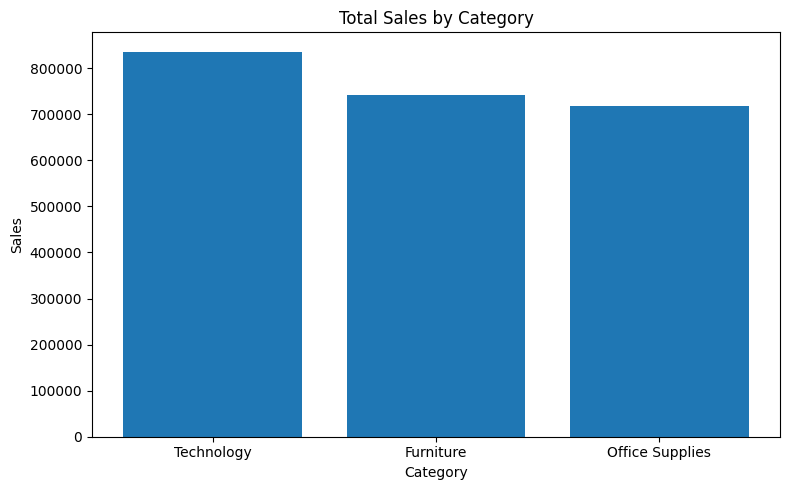

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(category_sales["Category"], category_sales["total_sales"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [32]:
query = """
SELECT Category, ROUND(SUM(Profit), 2) AS total_profit
FROM sales
GROUP BY Category
ORDER BY total_profit DESC
"""

category_profit = pd.read_sql_query(query, conn)
category_profit

,Category,total_profit
0,Technology,145454.95
1,Office Supplies,122490.80
2,Furniture,18451.27


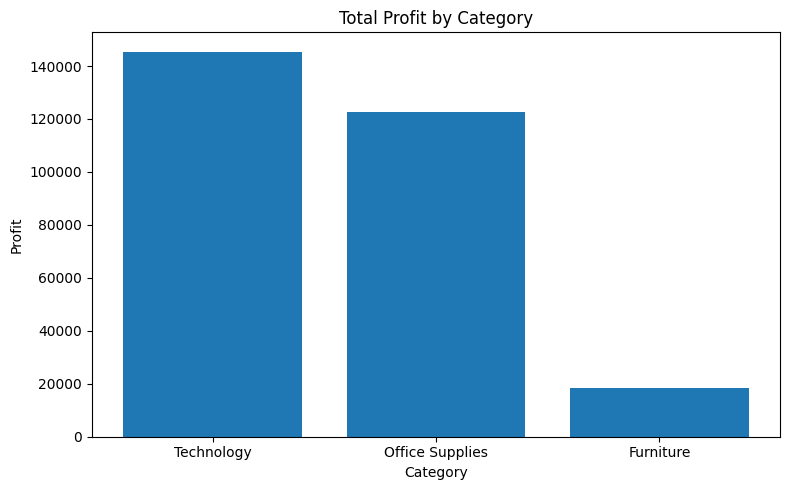

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(category_profit["Category"], category_profit["total_profit"])
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [34]:
query = """
SELECT "Customer Name" AS customer_name,
    ROUND(SUM(Sales), 2) AS total_sales
FROM sales
GROUP BY "Customer Name"
ORDER BY total_sales DESC
LIMIT 10 
""" 
top_customers = pd.read_sql_query(query, conn)
top_customers

,customer_name,total_sales
0,Sean Miller,25043.05
1,Tamara Chand,19052.22
2,Raymond Buch,15117.34
3,Tom Ashbrook,14595.62
4,Adrian Barton,14473.57
5,Ken Lonsdale,14175.23
6,Sanjit Chand,14142.33
7,Hunter Lopez,12873.30
8,Sanjit Engle,12209.44
9,Christopher Conant,12129.07


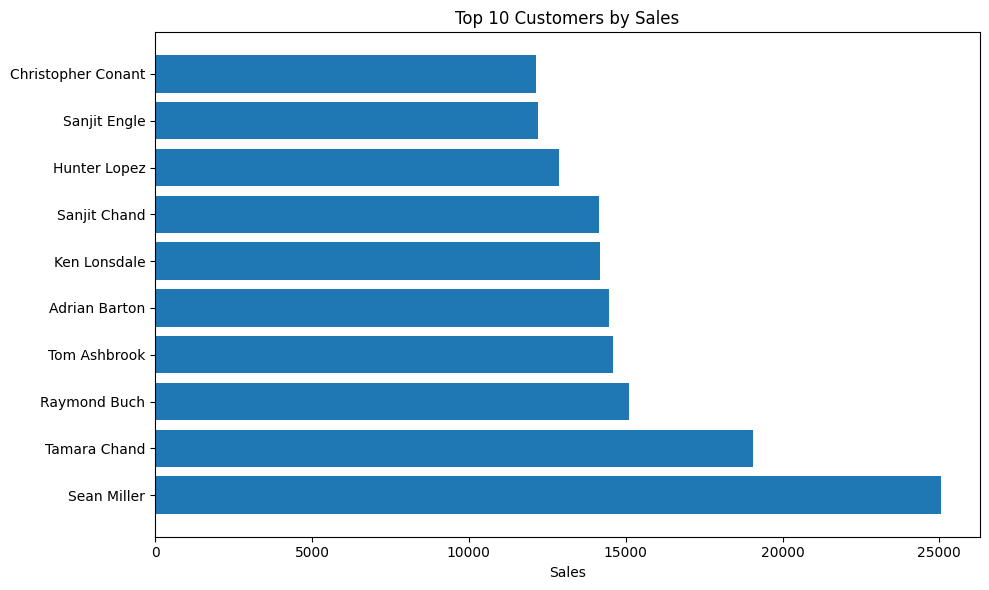

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(top_customers["customer_name"], top_customers["total_sales"])
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

In [36]:
query = """
SELECT Region, ROUND(SUM(Sales), 2) AS total_sales
FROM sales
GROUP BY Region
ORDER BY total_sales DESC
""" 

region_sales = pd.read_sql_query(query, conn)
region_sales

,Region,total_sales
0,West,725457.82
1,East,678781.24
2,Central,501239.89
3,South,391721.91


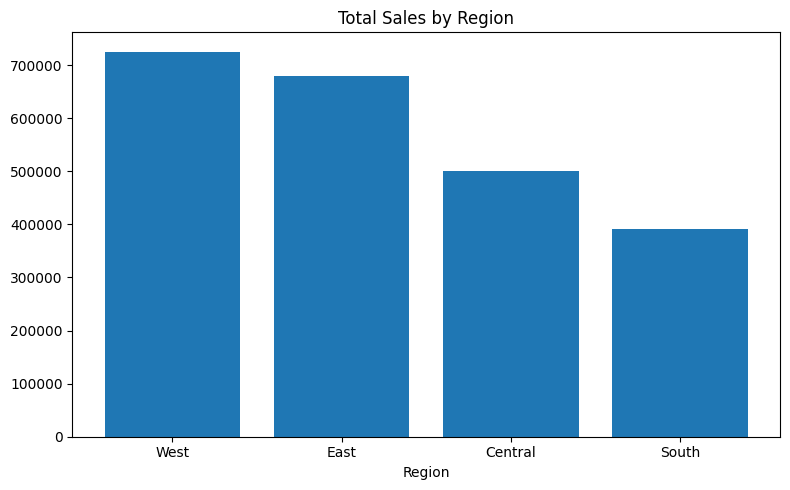

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(region_sales["Region"], region_sales["total_sales"])
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.tight_layout()
plt.show()